In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import altair as alt


from utils import make_barchart_annotations
from utils import get_threshold
from utils import get_mean_ens_triggers
from utils import obs_chart_with_triggers
from utils import decision_table
from utils import round_list
from utils import replace_with_list
from utils import plot_data_table

from utils import create_month_column
from utils import pass_month_get_colnames
from utils import legend_maker

/home/sparrow/micromamba/envs/indices_aa/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

data_path=os.getenv("data_path")

latex_path=os.getenv("latex_path")

print(latex_path)
print(data_path)

/home/sparrow/Documents/08-2023/impact_weather_icpac/lab/01_historical_impact_analysis/KEN-ibf-thresholds-triggers/xarray_input/
/home/sparrow/Documents/08-2023/impact_weather_icpac/lab/01_historical_impact_analysis/KEN-ibf-thresholds-triggers/xarray_input/


# Region 0, Karamoja

In [4]:
region_id=0
season_str='MAM'
sc_season_str=season_str.lower()
row_annotations=make_barchart_annotations()
threshold_dict=get_threshold(region_id, sc_season_str)


lead_int=2
obs_df,fct_df,metrix_df_lt2,dec_dict,dec_df2,plot_df=get_mean_ens_triggers(region_id,season_str,lead_int)
obs_plot=obs_chart_with_triggers('obs',obs_df, 'year', 'spi3', threshold_dict,row_annotations[2])
lt2_plot=obs_chart_with_triggers('fct',plot_df, 'year', 'ep_pb', dec_dict,row_annotations[1])


lead_int=3
obs_df,fct_df,metrix_df_lt3,dec_dict,dec_df3,plot_df=get_mean_ens_triggers(region_id,season_str,lead_int)
lt3_plot=obs_chart_with_triggers('fct',plot_df, 'year', 'ep_pb', dec_dict,row_annotations[2])

lead_int=4
obs_df,fct_df,metrix_df_lt4,dec_dict,dec_df4,plot_df=get_mean_ens_triggers(region_id,season_str,lead_int)
lt4_plot=obs_chart_with_triggers('fct',plot_df, 'year', 'ep_pb', dec_dict,row_annotations[3])

dec_lt2=dec_df2.drop_duplicates('cat')
dec_lt3=dec_df3.drop_duplicates('cat')
dec_lt4=dec_df4.drop_duplicates('cat')

tab_df=pd.concat([dec_lt2,dec_lt3,dec_lt4])
tab_df1=tab_df.reset_index().rename(columns={'index': 'idx'})
tab_df2=tab_df1[['lead_time','trigger_values','cat','trigger_values','hits','misses','FA','CN']]
tab_df2=tab_df2.rename(columns={"trigger_values": "Trigger"})
tab_df2=tab_df2.round({'Trigger': 1})
tab_df2['Trigger']=tab_df2['Trigger'].astype(str)

/home/sparrow/micromamba/envs/indices_aa/lib/python3.11/site-packages/geopandas/array.py:1459: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
/home/sparrow/micromamba/envs/indices_aa/lib/python3.11/site-packages/geopandas/array.py:1459: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))
/home/sparrow/micromamba/envs/indices_aa/lib/python3.11/site-packages/geopandas/array.py:1459: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [5]:
tab_df

,region,season,cat,year,trigger_values,threshold,#dry-seas,hits,misses,FA,CN,hit_rates,false_alarm_ratios,bias_scores,hanssen_kuipers_scores,heidke_skill_scores,auroc_scores,auroc_lb,auroc_ub,lead_time
2,0,MAM,mod,1995,30.808081,-0.03,42,5,12,2,23,0.294118,0.285714,0.411765,5.0,2.166667,0.500209,0.392758,0.618080,2
2,0,MAM,sev,2019,17.825312,-0.56,42,5,6,3,28,0.454545,0.375000,0.727273,5.0,2.904762,0.502513,0.382343,0.646628,2
2,0,MAM,ext,2000,13.517528,-0.99,42,3,5,3,31,0.375000,0.500000,0.750000,3.0,1.857143,0.502669,0.387097,0.659459,2
2,0,MAM,mod,2019,27.480689,-0.03,42,6,11,4,21,0.352941,0.400000,0.588235,6.0,1.952381,0.503133,0.375000,0.640794,3
1,0,MAM,sev,2007,18.478907,-0.56,42,3,8,6,25,0.272727,0.666667,0.818182,3.0,0.642857,0.502818,0.362465,0.661804,3
2,0,MAM,ext,2006,16.191325,-0.99,42,0,8,1,33,0.000000,1.000000,0.125000,-1.0,-0.190476,0.501098,0.460526,0.591765,3
1,0,MAM,mod,2004,24.896019,-0.03,42,7,10,6,19,0.411765,0.461538,0.764706,7.0,1.738095,0.501073,0.345428,0.656916,4
2,0,MAM,sev,2014,23.707665,-0.56,42,1,10,1,30,0.090909,0.500000,0.181818,1.0,0.476190,0.500453,0.437500,0.584375,4
2,0,MAM,ext,2012,14.408794,-0.99,42,0,8,4,30,0.000000,1.000000,0.500000,-1.0,-0.761905,0.501543,0.409091,0.659459,4


In [6]:
tab_df_a=tab_df.rename(columns={"lead_time":"lt"})
tab_df_m=create_month_column(tab_df_a)


tab_df_m['pod_v'] = tab_df_m.apply(lambda x: [x['hit_rates'], x['trigger_values']], axis=1)
tab_df_m['far_v'] = tab_df_m.apply(lambda x: [x['false_alarm_ratios'], x['trigger_values']], axis=1)

tab_df_m['pod_v'] = tab_df_m['pod_v'].apply(lambda x: round_list(x, 2))
tab_df_m['far_v'] = tab_df_m['far_v'].apply(lambda x: round_list(x, 2))


mapping_dict = {0: 'Karamoja', 1: 'Marsabit', 2: 'Wajir'}

tab_df_m['region_x'] = tab_df_m['region'].replace(mapping_dict)

p = tab_df_m.pivot_table(index=['region_x', 'season'], 
                            columns='new_column', 
                            values='pod_v', 
                            aggfunc='first')

pf = p.reset_index()


# Apply the custom function to each cell in the DataFrame
pf1 = pf.applymap(replace_with_list)

pf1.columns.name = None

pf1['empty1']=[[-999.0, -999.0]]* len(pf1)
pf1['empty2']=[[-999.0, -999.0]]* len(pf1)

months = ['jul', 'aug', 'sep']

organized_list=pass_month_get_colnames(months)

pf2=pf1[organized_list]
# pivoted_df1.to_csv(f'{data_path}pod.csv')
stat_var='POD'
mask = (pf2['region_x'].isin(['Marsabit', 'Wajir'])) & (pf2['season'] == 'OND')
pf3 = pf2[mask]

plot_data_table(pf3,stat_var,organized_list)


/tmp/ipykernel_394639/2960586910.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pf1 = pf.applymap(replace_with_list)


KeyError: "['jul_x', 'aug_x', 'sep_x', 'jul_y', 'aug_y', 'sep_y', 'jul_z', 'aug_z', 'sep_z'] not in index"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   region_x  1 non-null      object
 1   season    1 non-null      object
 2   jul_x     1 non-null      object
 3   aug_x     1 non-null      object
 4   sep_x     1 non-null      object
 5   empty1    1 non-null      object
 6   jul_y     1 non-null      object
 7   aug_y     1 non-null      object
 8   sep_y     1 non-null      object
 9   empty2    1 non-null      object
 10  jul_z     1 non-null      object
 11  aug_z     1 non-null      object
 12  sep_z     1 non-null      object
dtypes: object(13)
memory usage: 236.0+ bytes
None
Region
SPI
Jul
Aug
Sep

Jul
Aug
Sep

Jul
Aug
Sep


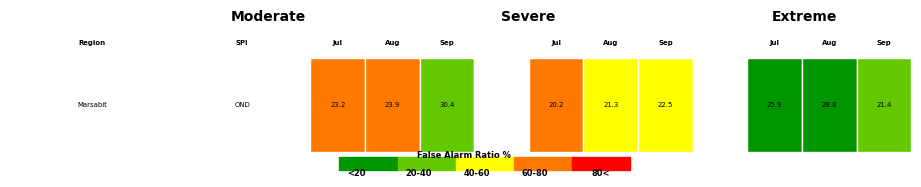

In [20]:
stat_var='FAR'
mask = (pf2['region_x'].isin(['Marsabit', 'Wajir'])) & (pf2['season'] == 'OND')
pf3 = pf2[mask]
plot_data_table(pf3,stat_var,organized_list)

In [7]:


#tab_df3=tab_df2[['lead_time','Trigger','cat']]

tab_plot=decision_table(tab_df2).properties(height=200,width=400)
#tab_plot


emtpy_plot=alt.Chart(pd.DataFrame({'A': []})).mark_text().encode().properties(
    width=400,
    height=200)

panels = alt.vconcat(
    alt.hconcat(obs_plot,lt2_plot),
    alt.hconcat(tab_plot, lt3_plot),
    alt.hconcat(emtpy_plot, lt4_plot),
)

panels.configure_view(stroke=None).configure_axisY(
    labelFontSize=12,
    titleFontSize=14
).configure_axisX(
    labelFontSize=10,
    titleFontSize=12
).configure_legend(
    labelFontSize=12,
    titleFontSize=14
)

print(' Marsabit selected trigger for OND')
#panels.save(f"{latex_path}{region_id}-{sc_season_str}_v20240626.png")
panels

 Marsabit selected trigger for OND


/home/sparrow/micromamba/envs/indices_aa/lib/python3.11/site-packages/altair/utils/data.py:227: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  return {"values": data.to_dict(orient="records")}


alt.VConcatChart(...)

In [8]:
df0=metrix_df_lt2
df=df0[df0['auroc_scores']>=0.5]
df1=df.round(2)
df1.columns=['region', 'season', 'cat', 'year', 'tri. val', 'thres.',
       'dry-seas', 'hits', 'misses', 'FA', 'CN', 'POD',
       'FAR', 'Bias S.', 'HKS',
       'HSS', 'auroc s.', 'a. lb', 'a. ub']

df1.drop(columns=['region','season','a. lb'], inplace=True)

cat_order = ['ext', 'sev', 'mod']

# Convert 'cat' column to categorical with the desired order
df1['cat'] = pd.Categorical(df1['cat'], categories=cat_order, ordered=True)
#df_sorted = df1.sort_values(by='cat')
df_sorted1=df1.sort_values(by=['cat','tri. val'])
#df_sorted2=df_sorted1.sort_values(by='cat')

region_name=mapping_dict[region_id] 
# To display all columns
pd.set_option('display.max_columns', None)

# To display all rows
pd.set_option('display.max_rows', None)
print('Table 1: Verification metrices for region Marsabit for lead time 2')
df_sorted1
#latex_table = df_sorted1.to_latex(index=False, longtable=True,float_format='%.2f',caption=f'Verification metrices for region {region_name} for lead time 2, Sep')
#latex_table

Table 1: Verification metrices for region Marsabit for lead time 2


,cat,year,tri. val,thres.,dry-seas,hits,misses,FA,CN,POD,FAR,Bias S.,HKS,HSS,auroc s.,a. ub
0,ext,2016,1.66,-0.99,42,8,0,34,0,1.00,0.81,5.25,8.0,0.00,0.50,0.50
0,ext,1990,1.81,-0.99,42,8,0,33,1,1.00,0.80,5.12,8.0,0.19,0.50,0.55
0,ext,2001,1.96,-0.99,42,8,0,32,2,1.00,0.80,5.00,8.0,0.38,0.50,0.56
0,ext,2010,3.36,-0.99,42,8,0,30,4,1.00,0.79,4.75,8.0,0.76,0.50,0.59
0,ext,2007,3.68,-0.99,42,8,0,29,5,1.00,0.78,4.62,8.0,0.95,0.50,0.60
0,ext,1991,4.10,-0.99,42,8,0,27,7,1.00,0.77,4.38,8.0,1.33,0.50,0.63
0,ext,2020,4.16,-0.99,42,8,0,26,8,1.00,0.76,4.25,8.0,1.52,0.50,0.64
0,ext,2004,4.34,-0.99,42,8,0,25,9,1.00,0.76,4.12,8.0,1.71,0.50,0.65
0,ext,1998,4.55,-0.99,42,8,0,24,10,1.00,0.75,4.00,8.0,1.90,0.50,0.65
0,ext,1999,4.69,-0.99,42,6,2,24,10,0.75,0.80,3.75,6.0,0.29,0.50,0.67


In [9]:
df0=metrix_df_lt3
df=df0[df0['auroc_scores']>=0.5]
df1=df.round(2)
df1.columns=['region', 'season', 'cat', 'year', 'tri. val', 'thres.',
       'dry-seas', 'hits', 'misses', 'FA', 'CN', 'POD',
       'FAR', 'Bias S.', 'HKS',
       'HSS', 'auroc s.', 'a. lb', 'a. ub']

df1.drop(columns=['region','season','a. lb'], inplace=True)

cat_order = ['ext', 'sev', 'mod']

# Convert 'cat' column to categorical with the desired order
df1['cat'] = pd.Categorical(df1['cat'], categories=cat_order, ordered=True)
#df_sorted = df1.sort_values(by='cat')
df_sorted1=df1.sort_values(by=['cat','tri. val'])
#df_sorted2=df_sorted1.sort_values(by='cat')

region_name=mapping_dict[region_id] 
pd.set_option('display.max_columns', None)

# To display all rows
pd.set_option('display.max_rows', None)
print('Table 2: Verification metrices for region Marsabit for lead time 3')
df_sorted1

Table 2: Verification metrices for region Marsabit for lead time 3


,cat,year,tri. val,thres.,dry-seas,hits,misses,FA,CN,POD,FAR,Bias S.,HKS,HSS,auroc s.,a. ub
0,ext,2020,0.12,-0.99,42,8,0,34,0,1.00,0.81,5.25,8.0,0.00,0.50,0.50
0,ext,1994,1.40,-0.99,42,7,1,33,1,0.88,0.82,5.00,7.0,-0.62,0.50,0.56
0,ext,1990,2.85,-0.99,42,7,1,30,4,0.88,0.81,4.62,7.0,-0.05,0.50,0.61
0,ext,2022,2.88,-0.99,42,7,1,29,5,0.88,0.81,4.50,7.0,0.14,0.50,0.62
0,ext,2012,3.36,-0.99,42,7,1,28,6,0.88,0.80,4.38,7.0,0.33,0.50,0.63
0,ext,2018,3.54,-0.99,42,6,2,27,7,0.75,0.82,4.12,6.0,-0.29,0.50,0.65
0,ext,2003,3.92,-0.99,42,6,2,26,8,0.75,0.81,4.00,6.0,-0.10,0.50,0.66
0,ext,1983,4.52,-0.99,42,6,2,25,9,0.75,0.81,3.88,6.0,0.10,0.50,0.66
0,ext,2014,5.88,-0.99,42,5,3,24,10,0.62,0.83,3.62,5.0,-0.52,0.51,0.68
0,ext,2010,5.94,-0.99,42,5,3,22,12,0.62,0.81,3.38,5.0,-0.14,0.50,0.69


In [10]:
df0=metrix_df_lt4
df=df0[df0['auroc_scores']>=0.5]
df1=df.round(2)
df1.columns=['region', 'season', 'cat', 'year', 'tri. val', 'thres.',
       'dry-seas', 'hits', 'misses', 'FA', 'CN', 'POD',
       'FAR', 'Bias S.', 'HKS',
       'HSS', 'auroc s.', 'a. lb', 'a. ub']

df1.drop(columns=['region','season','a. lb'], inplace=True)

cat_order = ['ext', 'sev', 'mod']

# Convert 'cat' column to categorical with the desired order
df1['cat'] = pd.Categorical(df1['cat'], categories=cat_order, ordered=True)
#df_sorted = df1.sort_values(by='cat')
df_sorted1=df1.sort_values(by=['cat','tri. val'])
#df_sorted2=df_sorted1.sort_values(by='cat')

region_name=mapping_dict[region_id] 
pd.set_option('display.max_columns', None)

# To display all rows
pd.set_option('display.max_rows', None)
print('Table 3: Verification metrices for region Marsabit for lead time 4')
df_sorted1

Table 3: Verification metrices for region Marsabit for lead time 4


,cat,year,tri. val,thres.,dry-seas,hits,misses,FA,CN,POD,FAR,Bias S.,HKS,HSS,auroc s.,a. ub
0,ext,2016,0.00,-0.99,42,8,0,34,0,1.00,0.81,5.25,8.0,0.00,0.5,0.50
0,ext,2015,2.44,-0.99,42,8,0,33,1,1.00,0.80,5.12,8.0,0.19,0.5,0.54
0,ext,2011,3.74,-0.99,42,8,0,30,4,1.00,0.79,4.75,8.0,0.76,0.5,0.59
0,ext,1982,3.89,-0.99,42,8,0,29,5,1.00,0.78,4.62,8.0,0.95,0.5,0.60
0,ext,1998,4.34,-0.99,42,7,1,25,9,0.88,0.78,4.00,7.0,0.90,0.5,0.66
0,ext,2021,4.78,-0.99,42,6,2,25,9,0.75,0.81,3.88,6.0,0.10,0.5,0.67
0,ext,2001,5.61,-0.99,42,6,2,22,12,0.75,0.79,3.50,6.0,0.67,0.5,0.69
0,ext,2017,6.39,-0.99,42,5,3,21,13,0.62,0.81,3.25,5.0,0.05,0.5,0.69
0,ext,1991,8.56,-0.99,42,4,4,18,16,0.50,0.82,2.75,4.0,-0.19,0.5,0.71
0,ext,1997,8.85,-0.99,42,4,4,16,18,0.50,0.80,2.50,4.0,0.19,0.5,0.71
